In [1]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import random
from torch.optim import LBFGS
from tqdm import tqdm

import os
import sys
current_dir = os.path.abspath('')
grandparent_dir = os.path.dirname(os.path.dirname(os.path.dirname(current_dir)))
if grandparent_dir not in sys.path:
    sys.path.append(grandparent_dir)

from util import *
from model.PINN import PINNs


if not os.path.exists('results'):
    os.makedirs('results')

In [2]:
seed = 0
np.random.seed(seed)
random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)

device = 'cuda'

In [3]:
res, b_left, b_right, b_upper, b_lower = get_data([-1,1], [0,1], 256, 50)
res_test, _, _, _, _ = get_data([-1,1], [0,1], 512, 100)

res = torch.tensor(res, dtype=torch.float32, requires_grad=True).to(device)
b_left = torch.tensor(b_left, dtype=torch.float32, requires_grad=True).to(device)
b_right = torch.tensor(b_right, dtype=torch.float32, requires_grad=True).to(device)
b_upper = torch.tensor(b_upper, dtype=torch.float32, requires_grad=True).to(device)
b_lower = torch.tensor(b_lower, dtype=torch.float32, requires_grad=True).to(device)

x_res, t_res = res[:,0:1], res[:,1:2]
x_left, t_left = b_left[:,0:1], b_left[:,1:2]
x_right, t_right = b_right[:,0:1], b_right[:,1:2]
x_upper, t_upper = b_upper[:,0:1], b_upper[:,1:2]
x_lower, t_lower = b_lower[:,0:1], b_lower[:,1:2]

def init_weights(m):
    if isinstance(m, nn.Linear):
        nn.init.xavier_normal_(m.weight)
        m.bias.data.fill_(0.01)

In [4]:

k = nn.Parameter(torch.tensor([0.1], dtype=torch.float32, requires_grad=True, device=device))


In [5]:
from scipy.io import loadmat

mat = loadmat('./burgers_ref.mat')
x_ref = mat['X_star'][:,0:1]
t_ref = mat['X_star'][:,1:2]
u_ref = mat['u_star']

x_data = torch.tensor(x_ref, dtype=torch.float32, requires_grad=True).to(device)
t_data = torch.tensor(t_ref, dtype=torch.float32, requires_grad=True).to(device)
u_data = torch.tensor(u_ref, dtype=torch.float32, requires_grad=True).to(device)

In [6]:
model = PINNs(in_dim=2, hidden_dim=512, out_dim=1, num_layer=4).to(device)

model.apply(init_weights)
optim = LBFGS([*model.parameters(), k], line_search_fn='strong_wolfe')

print(model)
print(get_n_params(model))

PINNs(
  (linear): Sequential(
    (0): Linear(in_features=2, out_features=512, bias=True)
    (1): Tanh()
    (2): Linear(in_features=512, out_features=512, bias=True)
    (3): Tanh()
    (4): Linear(in_features=512, out_features=512, bias=True)
    (5): Tanh()
    (6): Linear(in_features=512, out_features=1, bias=True)
  )
)
527361


In [7]:
relative_l2_threshold = 0.1
monitor_reference = u_data.detach().cpu().numpy().reshape(-1, 1)

def get_monitor_prediction():
    with torch.no_grad():
        prediction = model(x_data, t_data)[:, 0:1]
    return prediction.reshape(-1, 1).cpu().numpy()

convergence_tracker = RelativeL2ConvergenceTracker(
    monitor_reference,
    relative_l2_threshold,
)
convergence_tracker.record(0.0, get_monitor_prediction())


1.0411957401742866

In [8]:
time_recorder = ModelTimeRecorder(device)
loss_track = []
k_track = []
k_track.append(k.item())

for i in tqdm(range(500)):
    def closure():
        pred_res = model(x_res, t_res)
        pred_left = model(x_left, t_left)
        pred_right = model(x_right, t_right)
        pred_upper = model(x_upper, t_upper)
        pred_lower = model(x_lower, t_lower)

        u_x = torch.autograd.grad(pred_res, x_res, grad_outputs=torch.ones_like(pred_res), retain_graph=True, create_graph=True)[0]
        u_xx = torch.autograd.grad(u_x, x_res, grad_outputs=torch.ones_like(u_x), retain_graph=True, create_graph=True)[0]
        u_t = torch.autograd.grad(pred_res, t_res, grad_outputs=torch.ones_like(pred_res), retain_graph=True, create_graph=True)[0]

        loss_res = torch.mean((u_t + pred_res*u_x - k*u_xx) ** 2)
        loss_bc = torch.mean((pred_upper - pred_lower) ** 2)
        loss_ic = torch.mean((pred_left[:,0] + torch.sin(torch.pi * x_left[:,0])) ** 2)

        u_data_pred = model(x_data, t_data)
        loss_data = torch.mean((u_data_pred - u_data) ** 2)

        loss_track.append([loss_res.item(), loss_bc.item(), loss_ic.item(), loss_data.item()])

        loss = loss_res + loss_bc + loss_ic + loss_data
        optim.zero_grad()
        loss.backward()
        return loss

    with time_recorder.record_training():
        optim.step(closure)

    convergence_tracker.record(
        time_recorder.training_time,
        get_monitor_prediction(),
    )
    k_track.append(k.item())

100%|██████████| 500/500 [07:12<00:00,  1.16it/s]


In [9]:
np.save('./results/burgers_loss_pinns.npy', loss_track)
torch.save(model.state_dict(), './results/burgers_pinns.pt')
np.save('./results/burgers_k_pinns.npy', k_track)

print('Loss Res: {:4f}, Loss_BC: {:4f}, Loss_IC: {:4f}, Loss_Data: {:4f}'.format(loss_track[-1][0], loss_track[-1][1], loss_track[-1][2], loss_track[-1][3]))
print('Train Loss: {:4f}'.format(np.sum(loss_track[-1])))
print('Final k: {:4f}'.format(k_track[-1]))

print('Training Time: {:.2f} s'.format(time_recorder.training_time))

np.save(
    './results/burgers_relative_l2_error_vs_training_time_pinns.npy',
    convergence_tracker.as_array(),
)
if convergence_tracker.first_threshold_time is None:
    print('Relative L2 threshold {:.3f} was not reached.'.format(relative_l2_threshold))
else:
    print(
        'Relative L2 threshold {:.3f} first reached at {:.6f} s'.format(
            relative_l2_threshold,
            convergence_tracker.first_threshold_time,
        )
    )


Loss Res: 0.000273, Loss_BC: 0.000000, Loss_IC: 0.000049, Loss_Data: 0.000145
Train Loss: 0.000467
Final k: 0.004100
Training Time: 429.18 s
Relative L2 threshold 0.100 first reached at 81.384166 s


Inference Time: 0.002997 s
relative L1 error: 0.006585
relative L2 error: 0.019614


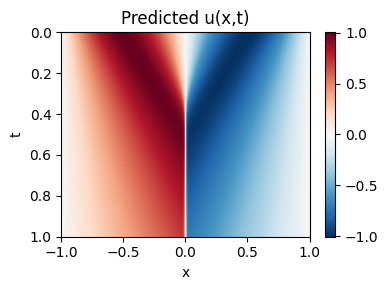

In [10]:
res_test = torch.tensor(res_test, dtype=torch.float32, requires_grad=True).to(device)
x_test, t_test = res_test[:,0:1], res_test[:,1:2]

with time_recorder.record_inference():
    with torch.no_grad():
        pred = model(x_test, t_test)[:,0:1]
        pred = pred.cpu().detach().numpy()
print('Inference Time: {:.6f} s'.format(time_recorder.inference_time))

pred = pred.reshape(100,512)

u = mat['u_star'].reshape(100,512)
rl1 = np.sum(np.abs(u-pred)) / np.sum(np.abs(u))
rl2 = np.sqrt(np.sum((u-pred)**2) / np.sum(u**2))
print('relative L1 error: {:4f}'.format(rl1))
print('relative L2 error: {:4f}'.format(rl2))

plt.figure(figsize=(4,3))
plt.imshow(pred, extent=[-1,1,1,0], aspect='auto', cmap='RdBu_r')
plt.xlabel('x')
plt.ylabel('t')
plt.title('Predicted u(x,t)')
plt.colorbar()
plt.tight_layout()
plt.savefig('./results/burgers_pinns_pred.png')
plt.show()

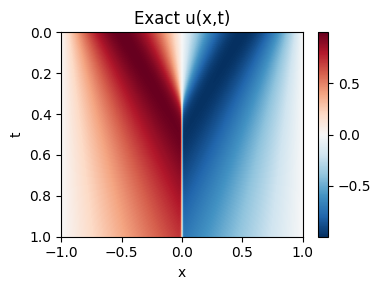

In [11]:
plt.figure(figsize=(4,3))
plt.imshow(u, extent=[-1,1,1,0], aspect='auto', cmap='RdBu_r')
plt.xlabel('x')
plt.ylabel('t')
plt.title('Exact u(x,t)')
plt.colorbar()
plt.tight_layout()
plt.savefig('./results/burgers_exact.png')
plt.show()

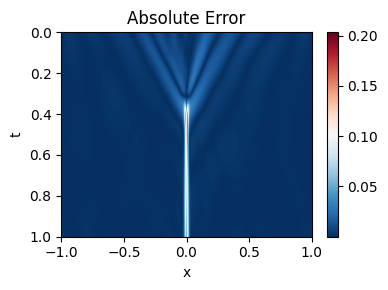

In [12]:
plt.figure(figsize=(4,3))
plt.imshow(np.abs(pred - u), extent=[-1,1,1,0], aspect='auto', cmap='RdBu_r')
plt.xlabel('x')
plt.ylabel('t')
plt.title('Absolute Error')
plt.colorbar()
plt.tight_layout()
plt.savefig('./results/burgers_pinns_error.png')
plt.show()

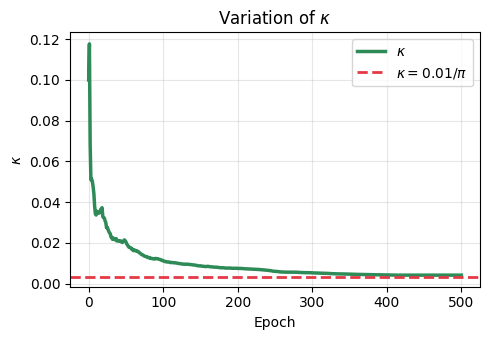

In [13]:

plt.figure(figsize=(5, 3.5))
plt.plot(k_track, label='$\kappa$', color='#2E8B57', linewidth=2.5)
plt.axhline(y=0.01/np.pi, color='#E63946', linestyle='--', linewidth=2, label='$\kappa=0.01/\pi$')
plt.xlabel('Epoch')
plt.ylabel('$\kappa$')
plt.title('Variation of $\kappa$')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

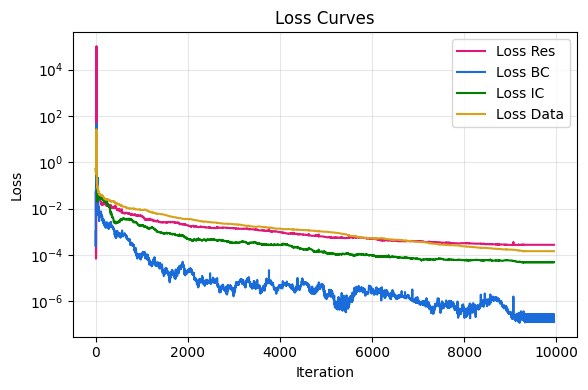

In [14]:

loss_track = np.array(loss_track)
plt.figure(figsize=(6,4))
plt.plot(loss_track[:,0], label='Loss Res', color="#de1978")
plt.plot(loss_track[:,1], label='Loss BC', color="#196cd9") 
plt.plot(loss_track[:,2], label='Loss IC', color="green")
plt.plot(loss_track[:,3], label='Loss Data', color="#d9a119")
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.yscale('log')
plt.title('Loss Curves')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()